> 📅 __Date: 2026-07-23__

# __Long Short-Term Memory (LSTM)__

A **Long Short-Term Memory (LSTM)** network is a special type of **Recurrent Neural Network (RNN)** designed to overcome the limitations of a Vanilla RNN.

Unlike a simple RNN, an LSTM can **learn long-term dependencies** by maintaining a separate **Cell State**, which acts as long-term memory.

This enables LSTMs to remember important information for long periods while forgetting irrelevant information.

---

# ⚠️ __1. Drawbacks of Vanilla RNN__

Although RNNs are designed for sequential data, they suffer from several limitations when processing long sequences.

## __1. Cannot Learn Long-Term Dependencies__

A Vanilla RNN performs well for short sequences but struggles to remember information that appeared many time steps earlier.

As the sequence becomes longer, earlier information gradually fades away.

### __Example__

Consider the sentence:

> "I grew up in **France**. ... I speak fluent French."

To correctly predict the word **French**, the model should remember that the person grew up in **France**.

A Vanilla RNN often fails to retain this information when the gap between related words becomes large.

---

## __2. Short-Term Memory__

The hidden state of a Vanilla RNN mainly stores **recent information**.

As new inputs arrive, older information is gradually overwritten.

Therefore, the network behaves like it has only **short-term memory**.

---

## __3. Vanishing Gradient Problem__

During training, RNNs use **Backpropagation Through Time (BPTT)** to update their weights.

As gradients are propagated backward through many time steps, they can become extremely small.

When this happens,

- Weight updates become very small.
- Earlier layers learn very slowly.
- The network fails to learn long-range dependencies.

This is known as the **Vanishing Gradient Problem**.

---

## __4. Exploding Gradient Problem__

Sometimes, instead of becoming very small, gradients become extremely large.

This causes

- Unstable training
- Large weight updates
- Diverging loss

This is known as the **Exploding Gradient Problem**.

> **Note:** The Vanishing Gradient Problem is much more common than the Exploding Gradient Problem in RNNs.

---

# ✅ __2. Why LSTM Was Introduced__

LSTM was proposed to overcome the limitations of Vanilla RNNs.

Instead of storing all information inside a single hidden state, LSTM introduces an additional memory called the **Cell State**.

This allows the network to

- Remember important information for a long time.
- Forget unnecessary information.
- Learn long-term dependencies more effectively.

---

# 🧠 __3. Long Short-Term Memory__

An LSTM maintains **two different states** while processing a sequence.

## __1. Hidden State ($h_t$)__

The **Hidden State** stores **short-term information**.

- Passed to the next time step.
- Used for generating the output.
- Represents the current context of the sequence.

---

## __2. Cell State ($C_t$)__

The **Cell State** stores **long-term information**.

It acts like a memory highway that carries important information across many time steps with very little modification.

Because of this, important information can survive for much longer than in a Vanilla RNN.

---

# 🔄 __4. Difference Between Hidden State and Cell State__

| Hidden State ($h_t$) | Cell State ($C_t$) |
|-----------------------|--------------------|
| Stores short-term information | Stores long-term information |
| Used to generate output | Acts as long-term memory |
| Changes significantly at every time step | Changes gradually over time |
| Passed to the next LSTM cell | Also passed to the next LSTM cell |

---

# 🏗️ __5. Basic Architecture of an LSTM Cell__

Unlike a Vanilla RNN, an LSTM cell receives

- Current input ($x_t$)
- Previous Hidden State ($h_{t-1}$)
- Previous Cell State ($C_{t-1}$)

It produces

- New Hidden State ($h_t$)
- New Cell State ($C_t$)

<div align="center">
    <img src="assets/lstm_cell.png" width="450" alt="LSTM Cell">
    <p><em>Figure: Basic architecture of an LSTM cell.</em></p>
</div>

The hidden state represents the short-term memory, whereas the cell state carries long-term memory throughout the sequence.

---

# 🚪 __6. Gates in LSTM__

One of the biggest innovations in LSTM is the introduction of **Gates**.

Gates control the flow of information through the Cell State.

Each gate is implemented using a **Sigmoid Activation Function**, whose output lies between **0 and 1**.

- **0** → Completely block the information.
- **1** → Completely allow the information.
- Values between **0 and 1** → Partially allow the information.

Thus, gates decide **what to forget**, **what to remember**, and **what to output**.

---

# ❌ __7. Forget Gate__

The **Forget Gate** decides which information should be removed from the previous Cell State.

It receives

- Previous Hidden State ($h_{t-1}$)
- Current Input ($x_t$)

It produces a vector

$$
f_t
$$

whose values lie between **0 and 1**.

The Forget Gate is computed as

$$
f_t=\sigma(W_f[h_{t-1},x_t]+b_f)
$$

where

- $\sigma$ → Sigmoid activation
- $W_f$ → Forget gate weights
- $b_f$ → Forget gate bias

### __Interpretation__

If

$$
f_t=0
$$

the corresponding information is forgotten.

If

$$
f_t=1
$$

the information is completely retained.

---

# ➕ __8. Input Gate__

The **Input Gate** decides what new information should be stored in the Cell State.

It consists of two parts.

## __Step 1: Decide What to Store__

The Input Gate computes

$$
i_t=\sigma(W_i[h_{t-1},x_t]+b_i)
$$

This determines which values should be updated.

---

## __Step 2: Create Candidate Memory__

A candidate Cell State is created using the tanh activation.

$$
\tilde{C_t}=tanh(W_c[h_{t-1},x_t]+b_c)
$$

This contains the new information that may be added to memory.

---

## __Updating Cell State__

The new Cell State is computed as

$$
C_t=f_t*C_{t-1}+i_t*\tilde{C_t}
$$

This equation performs two operations simultaneously.

- Forget unnecessary information.
- Add important new information.

---

# 📤 __9. Output Gate__

The **Output Gate** determines what information should be exposed as the Hidden State.

First,

$$
o_t=\sigma(W_o[h_{t-1},x_t]+b_o)
$$

Then,

$$
h_t=o_t*tanh(C_t)
$$

The Hidden State is then

- Sent to the next LSTM cell.
- Used to generate the output.

---

# 🔄 __10. Working of an LSTM Cell__

For every time step, the following operations occur.

### __Step 1__

Receive

- Current Input ($x_t$)
- Previous Hidden State ($h_{t-1}$)
- Previous Cell State ($C_{t-1}$)

---

### __Step 2__

Forget Gate removes unnecessary information from the Cell State.

---

### __Step 3__

Input Gate decides what new information should be stored.

---

### __Step 4__

Update the Cell State.

---

### __Step 5__

Output Gate generates the Hidden State.

---

### __Step 6__

Pass

- Hidden State ($h_t$)
- Cell State ($C_t$)

to the next LSTM cell.

---

# 📌 __11. Advantages of LSTM__

- Learns long-term dependencies.
- Solves the Vanishing Gradient Problem to a large extent.
- Maintains both short-term and long-term memory.
- Selectively remembers useful information.
- Selectively forgets irrelevant information.
- Performs well on long sequential data.

---

# ⚠️ __12. Limitations of LSTM__

Although LSTM is much better than Vanilla RNN, it still has some drawbacks.

- More parameters than Vanilla RNN.
- Slower training.
- Higher computational cost.
- Requires more memory.
- Difficult to parallelize because sequential information must be processed step by step.

---

# 🔄 __13. Difference Between RNN and LSTM__

| Vanilla RNN | LSTM |
|--------------|------|
| Only Hidden State | Hidden State + Cell State |
| Short-term memory | Short-term + Long-term memory |
| Suffers from Vanishing Gradient | Greatly reduces Vanishing Gradient |
| Poor for long sequences | Excellent for long sequences |
| Simple architecture | More complex architecture |
| Fewer parameters | More parameters |
| Faster training | Slower training |

---

# 📝 __Summary__

- **LSTM** is an improved version of a Vanilla RNN.
- It introduces a **Cell State** for storing long-term information.
- The **Hidden State** stores short-term information.
- LSTM uses **Forget**, **Input**, and **Output Gates** to control the flow of information.
- These gates allow the network to remember important information while forgetting irrelevant details.
- LSTM significantly reduces the **Vanishing Gradient Problem**, making it effective for learning long-term dependencies.
- Due to its ability to model sequential data, LSTM is widely used in **Sentiment Analysis**, **Machine Translation**, **Speech Recognition**, **Text Generation**, and many other Natural Language Processing (NLP) tasks.

---

# 🧪 __14. LSTM Project (IMDB Sentiment Analysis)__

In this project, we build an LSTM model to classify movie reviews as **Positive** or **Negative**.

---

# 📂 __1. Import Libraries__

In [1]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# 📥 __2. Load the Dataset__

The IMDB movie review dataset contains movie reviews along with their corresponding sentiment labels (**positive** or **negative**). We first load the dataset into a pandas DataFrame.

In [2]:
# Load the IMDB dataset
df = pd.read_csv("/content/IMDB Dataset.csv")

# Display the first five rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# 📊 __3. Exploratory Data Analysis (EDA)__

Before preprocessing the data, it is important to understand its structure and check for potential issues such as missing values or class imbalance.

---

## __3.1 View First Five Rows__

Display the first few rows to understand the structure of the dataset.

In [3]:
# Display the first five rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## __3.2 Check Dataset Shape__

The shape tells us the number of rows (samples) and columns (features) in the dataset.

In [4]:
# Check the number of rows and columns
df.shape

(50000, 2)

## __3.3 Check Missing Values__

Check whether any column contains missing values.

In [5]:
# Count missing values in each column
df.isna().sum()

,0
review,0
sentiment,0


## __3.4 Check Class Distribution__

Count the number of positive and negative reviews.

In [6]:
# Count reviews belonging to each sentiment class
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


## __3.5 Display a Sample Review__

Display a review to understand the raw text before preprocessing.

In [7]:
# Display a sample review
df["review"][8760]

"The only good thing about this movie was the shot of Goldie Hawn standing in her little french cut bikini panties and struggling to keep a dozen other depraved women from removing her skimpy little cotton top while she giggled and cooed. Ooooof! Her loins rival those of Nina Hartley. This movie came out when I was fourteen and that shot nearly killed me. I'd forgotten about it all tucked away in the naughty Roladex of my mind until seeing it the other day on TV, where they actually blurred her midsection in that scene, good grief, reminding me what a smokin' hottie of a woman Goldie Hawn was in the '80s. Kurt Russell must have had a fun life."

# 🧹 __4. Data Preprocessing__

Raw text usually contains HTML tags, punctuation, numbers, and inconsistent letter casing. Before feeding the text into an LSTM model, these unwanted elements should be removed so that the model can focus on meaningful textual information.

**The preprocessing steps include:**

- Removing HTML tags
- Removing non-alphabetic characters
- Converting text to lowercase
- Tokenization
- Removing stopwords (optional)
- Stemming/Lemmatization (optional)
- Converting text to sequences
- Padding sequences

## __4.1 Remove HTML Tags__

Movie reviews often contain HTML tags such as `<br>`, `<div>`, and `<p>`, which do not contribute to the meaning of the text.

Removing these tags helps the model focus only on the actual review content.

In [8]:
# Import BeautifulSoup for removing HTML tags
from bs4 import BeautifulSoup

# Function to remove HTML tags from a review
def remove_html(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

# Apply the function to every review
df["review"] = df["review"].apply(remove_html)

# Display a sample review after removing HTML tags
df["review"][8760]

"The only good thing about this movie was the shot of Goldie Hawn standing in her little french cut bikini panties and struggling to keep a dozen other depraved women from removing her skimpy little cotton top while she giggled and cooed. Ooooof! Her loins rival those of Nina Hartley. This movie came out when I was fourteen and that shot nearly killed me. I'd forgotten about it all tucked away in the naughty Roladex of my mind until seeing it the other day on TV, where they actually blurred her midsection in that scene, good grief, reminding me what a smokin' hottie of a woman Goldie Hawn was in the '80s. Kurt Russell must have had a fun life."

## __4.2 Remove Non-Alphabetic Characters__

Movie reviews may contain numbers, punctuation marks, and special characters.

These characters usually do not provide useful information for sentiment analysis, so they are removed, keeping only alphabetic characters.

In [9]:
# Import the regular expression module
import re

# Function to remove non-alphabetic characters
def remove_non_alpha(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

# Apply the function to every review
df["review"] = df["review"].apply(remove_non_alpha)

# Display a sample review
df["review"][8760]

'The only good thing about this movie was the shot of Goldie Hawn standing in her little french cut bikini panties and struggling to keep a dozen other depraved women from removing her skimpy little cotton top while she giggled and cooed Ooooof Her loins rival those of Nina Hartley This movie came out when I was fourteen and that shot nearly killed me Id forgotten about it all tucked away in the naughty Roladex of my mind until seeing it the other day on TV where they actually blurred her midsection in that scene good grief reminding me what a smokin hottie of a woman Goldie Hawn was in the s Kurt Russell must have had a fun life'

## __4.3 Convert Text to Lowercase__

Words such as **Movie**, **movie**, and **MOVIE** should be treated as the same word.

Converting all text to lowercase ensures consistency throughout the dataset.

In [10]:
# Convert every review to lowercase
df["review"] = df["review"].str.lower()

# Display a sample review
df["review"][8760]

'the only good thing about this movie was the shot of goldie hawn standing in her little french cut bikini panties and struggling to keep a dozen other depraved women from removing her skimpy little cotton top while she giggled and cooed ooooof her loins rival those of nina hartley this movie came out when i was fourteen and that shot nearly killed me id forgotten about it all tucked away in the naughty roladex of my mind until seeing it the other day on tv where they actually blurred her midsection in that scene good grief reminding me what a smokin hottie of a woman goldie hawn was in the s kurt russell must have had a fun life'

## __4.4 Tokenization__

Tokenization is the process of splitting a sentence into individual words called **tokens**.

These tokens become the basic units that the model processes.

In [11]:
# Import the tokenizer from NLTK
from nltk.tokenize import word_tokenize
import nltk

# Download tokenizer resources
nltk.download("punkt_tab")

# Convert each review into a list of words
df["review"] = df["review"].apply(word_tokenize)

# Display a sample tokenized review
print(df["review"][8760])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['the', 'only', 'good', 'thing', 'about', 'this', 'movie', 'was', 'the', 'shot', 'of', 'goldie', 'hawn', 'standing', 'in', 'her', 'little', 'french', 'cut', 'bikini', 'panties', 'and', 'struggling', 'to', 'keep', 'a', 'dozen', 'other', 'depraved', 'women', 'from', 'removing', 'her', 'skimpy', 'little', 'cotton', 'top', 'while', 'she', 'giggled', 'and', 'cooed', 'ooooof', 'her', 'loins', 'rival', 'those', 'of', 'nina', 'hartley', 'this', 'movie', 'came', 'out', 'when', 'i', 'was', 'fourteen', 'and', 'that', 'shot', 'nearly', 'killed', 'me', 'id', 'forgotten', 'about', 'it', 'all', 'tucked', 'away', 'in', 'the', 'naughty', 'roladex', 'of', 'my', 'mind', 'until', 'seeing', 'it', 'the', 'other', 'day', 'on', 'tv', 'where', 'they', 'actually', 'blurred', 'her', 'midsection', 'in', 'that', 'scene', 'good', 'grief', 'reminding', 'me', 'what', 'a', 'smokin', 'hottie', 'of', 'a', 'woman', 'goldie', 'hawn', 'was', 'in', 'the', 's', 'kurt', 'russell', 'must', 'have', 'had', 'a', 'fun', 'life']


## __4.5 Remove Stopwords (Optional)__

Stopwords are very common words such as **the**, **is**, **and**, and **of**.

These words usually carry little semantic meaning and can be removed to reduce noise in the dataset.

> **Note:** In sentiment analysis, stopword removal is optional because words like **not**, **no**, and **never** may carry important sentiment information.

In [12]:
# Import stopwords from NLTK
from nltk.corpus import stopwords

# Download the stopwords dataset
nltk.download("stopwords")

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords from each review
df["review"] = df["review"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

# Display a sample review
print(df["review"][8760])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['good', 'thing', 'movie', 'shot', 'goldie', 'hawn', 'standing', 'little', 'french', 'cut', 'bikini', 'panties', 'struggling', 'keep', 'dozen', 'depraved', 'women', 'removing', 'skimpy', 'little', 'cotton', 'top', 'giggled', 'cooed', 'ooooof', 'loins', 'rival', 'nina', 'hartley', 'movie', 'came', 'fourteen', 'shot', 'nearly', 'killed', 'id', 'forgotten', 'tucked', 'away', 'naughty', 'roladex', 'mind', 'seeing', 'day', 'tv', 'actually', 'blurred', 'midsection', 'scene', 'good', 'grief', 'reminding', 'smokin', 'hottie', 'woman', 'goldie', 'hawn', 'kurt', 'russell', 'must', 'fun', 'life']


## __4.6 Stemming / Lemmatization (Optional)__

Stemming and Lemmatization reduce words to their root form.

This helps group different forms of the same word into a single representation.

### __Example__

- playing → play
- played → play
- plays → play

There are two common approaches:

### __Option 1: Stemming__

Stemming removes prefixes or suffixes to obtain the root form of a word. It is faster but may produce words that are not actual dictionary words.

```python
# Import Porter Stemmer
from nltk.stem import PorterStemmer

# Create a stemmer object
stemmer = PorterStemmer()

# Apply stemming
df["review"] = df["review"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

# Display a sample review
df["review"][8760]
```

---

### __Option 2: Lemmatization__

Lemmatization converts words to their dictionary (base) form. It is generally more accurate than stemming but requires additional linguistic information.

```python
# Import WordNet Lemmatizer
from nltk.stem import WordNetLemmatizer
import nltk

# Download the WordNet dataset
nltk.download("wordnet")

# Create a lemmatizer object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization
df["review"] = df["review"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

# Display a sample review
df["review"][8760]
```

> **Note:** Only one of the above methods should be applied during preprocessing. Later, we will compare the model performance using **Stemming** and **Lemmatization** separately to determine which approach works better for sentiment analysis.

In [13]:
# Import Porter Stemmer
from nltk.stem import PorterStemmer

# Create a stemmer object
stemmer = PorterStemmer()

# Apply stemming
df["review"] = df["review"].apply(
    lambda words: [stemmer.stem(word) for word in words]
)

# Display a sample review
print(df["review"][8760])

['good', 'thing', 'movi', 'shot', 'goldi', 'hawn', 'stand', 'littl', 'french', 'cut', 'bikini', 'panti', 'struggl', 'keep', 'dozen', 'deprav', 'women', 'remov', 'skimpi', 'littl', 'cotton', 'top', 'giggl', 'coo', 'ooooof', 'loin', 'rival', 'nina', 'hartley', 'movi', 'came', 'fourteen', 'shot', 'nearli', 'kill', 'id', 'forgotten', 'tuck', 'away', 'naughti', 'roladex', 'mind', 'see', 'day', 'tv', 'actual', 'blur', 'midsect', 'scene', 'good', 'grief', 'remind', 'smokin', 'hotti', 'woman', 'goldi', 'hawn', 'kurt', 'russel', 'must', 'fun', 'life']


## __4.7 Convert Text to Sequences__

Deep Learning models cannot process text directly.

Each unique word is assigned a unique integer index using a **Tokenizer**, converting every review into a sequence of integers.

In [14]:
# Import the Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Convert token lists back to sentences
reviews = df["review"].apply(lambda words: " ".join(words))

# Create a tokenizer
tokenizer = Tokenizer()

# Build the vocabulary
tokenizer.fit_on_texts(reviews)

# Convert text into integer sequences
sequences = tokenizer.texts_to_sequences(reviews)

# Display the first sequence
print(sequences[0])

[3, 232, 357, 11, 2822, 194, 407, 1589, 117, 548, 113, 5243, 30, 34, 2775, 2822, 1081, 10951, 16, 536, 94, 117, 297, 25, 1367, 17, 4920, 406, 8268, 17, 577, 1684, 1071, 654, 329, 536, 2918, 238, 63, 41714, 171, 2822, 6038, 303, 10768, 5372, 1813, 519, 41715, 1093, 1267, 16680, 444, 3342, 1903, 776, 1905, 1786, 870, 236, 17308, 12345, 265, 3722, 3096, 444, 287, 58576, 3439, 9283, 5764, 1063, 918, 2146, 12346, 15097, 245, 2013, 5765, 416, 6594, 6280, 49, 158, 14658, 14, 38, 205, 797, 17, 599, 101, 199, 17, 490, 1474, 678, 106, 285, 1038, 2179, 186, 678, 623, 678, 58577, 74, 743, 109, 30, 194, 55, 131, 2775, 1365, 1720, 351, 38, 1410, 11, 370, 926, 2822, 104, 7570, 265, 481, 1190, 536, 536, 5148, 2919, 1728, 10199, 2552, 18780, 4312, 10199, 102, 467, 8, 174, 19, 1016, 693, 646, 4312, 98, 776, 4049, 599, 293, 619, 985, 776, 352, 11, 2822, 120, 136, 1773, 2581, 58578, 8, 450, 3343, 389]


## __4.8 Padding Sequences__

Different reviews contain different numbers of words.

Deep Learning models require all input sequences to have the same length.

Padding adds zeros to shorter sequences (or truncates longer ones) so that every sequence has a fixed length.

In [15]:
# Import pad_sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set the maximum sequence length
max_length = 200

# Pad all sequences to the same length
X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Display the shape of the padded data
X.shape

(50000, 200)

# 🤖 __5. Prepare the Data for Training__

Before training the LSTM model, we need to prepare the input features and target labels.

The movie reviews (after padding) will be used as the input features (**X**), while the sentiment labels will be converted into numerical values (**y**).

In [16]:
# Convert sentiment labels into numerical values
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# Input features
X = X

# Target labels
y = df["sentiment"]

# Display the first few labels
y.head()

,sentiment
0,1
1,1
2,1
3,0
4,1


# ✂️ __6. Split the Dataset__

The dataset is divided into **training** and **testing** sets.

- **Training Set:** Used to train the model.
- **Testing Set:** Used to evaluate the model on unseen data.

In [17]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (40000, 200)
Testing Data : (10000, 200)


# 🏗️ __7. Build the LSTM Model__

Now we create the LSTM model using Keras.

The model consists of:

- Embedding Layer
- LSTM Layer
- Dense Output Layer

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

## __7.1 Define the Model__

In [19]:
# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

# Create the model
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(128),
    Dense(1, activation="sigmoid")
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │    22,376,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,508,673 (85.86 MB)

 Trainable params: 22,508,673 (85.86 MB)

 Non-trainable params: 0 (0.00 B)

# ⚙️ __8. Compile the Model__

Before training, the model must be compiled by specifying:

- Optimizer
- Loss Function
- Evaluation Metric

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 🚀 __9. Train the Model__

The model learns patterns from the training dataset over multiple epochs.

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 611s 609ms/step - accuracy: 0.5106 - loss: 0.6918 - val_accuracy: 0.4996 - val_loss: 0.6942
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 585s 585ms/step - accuracy: 0.5566 - loss: 0.6597 - val_accuracy: 0.6146 - val_loss: 0.6514
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 618s 581ms/step - accuracy: 0.7798 - loss: 0.4525 - val_accuracy: 0.8386 - val_loss: 0.3935
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 595s 595ms/step - accuracy: 0.9127 - loss: 0.2297 - val_accuracy: 0.8637 - val_loss: 0.3274
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 589s 589ms/step - accuracy: 0.9568 - loss: 0.1323 - val_accuracy: 0.8680 - val_loss: 0.3516


# 📊 __10. Evaluate the Model__

After training, evaluate the model using the testing dataset.

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.8647 - loss: 0.3479
Test Loss: 0.34785643219947815
Test Accuracy: 0.8647000193595886


# 🔮 __11. Make Predictions__

Use the trained model to predict the sentiment of unseen reviews.

In [23]:
predictions = model.predict(X_test)

predictions[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step


array([[0.04150385],
       [0.9013862 ],
       [0.03856529],
       [0.981048  ],
       [0.21029085]], dtype=float32)

# 📈 __12. Visualize Training Performance__

Plot the training and validation accuracy and loss to observe how the model learned during training.

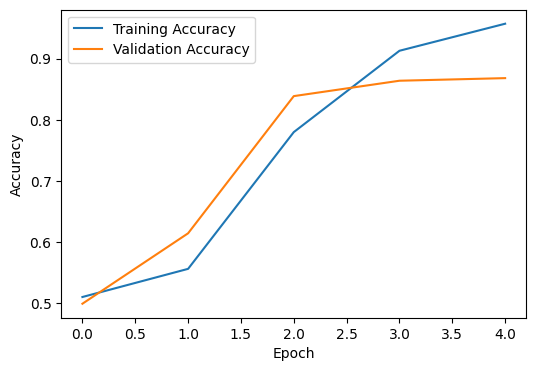

In [24]:
import matplotlib.pyplot as plt

# Plot training accuracy
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 📝 __Project Summary__

In this project, we built an **LSTM-based Sentiment Analysis** model using the **IMDB Movie Review Dataset**.

The workflow followed these major steps:

- Loaded the IMDB movie review dataset.
- Performed **Exploratory Data Analysis (EDA)** to understand the dataset.
- Cleaned the review text by removing HTML tags, non-alphabetic characters, and converting text to lowercase.
- Applied **Tokenization** to split reviews into individual words.
- Optionally performed **Stopword Removal** and **Stemming/Lemmatization** to further preprocess the text.
- Converted the processed text into integer sequences using the **Tokenizer**.
- Applied **Padding** to ensure all input sequences had the same length.
- Split the dataset into **training** and **testing** sets.
- Built an **LSTM model** consisting of an **Embedding Layer**, an **LSTM Layer**, and a **Dense Output Layer**.
- Compiled and trained the model on the training dataset.
- Evaluated the model using the testing dataset.
- Used the trained model to predict the sentiment of unseen movie reviews.

This project demonstrates the complete workflow of applying **Long Short-Term Memory (LSTM)** networks for **Natural Language Processing (NLP)** tasks, specifically **binary sentiment classification**.